# Megabytes and Two's Complement: The Ravioli_Recipe_AI Byte Budget

**"Ravioli_Recipe_AI" is a playful placeholder theme, not a real project** --
a toy AI that scales pasta-filling quantities, used only to make byte-level
arithmetic concrete. The real engineering content is one genuine tradeoff:
**int8 quantization saves memory (the megabytes side) but risks signed
overflow (the two's-complement side)** -- exactly the kind of bug that
shows up in real quantized neural networks and embedded systems.
Reuses `dgs/machine_modular_arithmetic.py` and `dgs/computer_architecture.py`
directly; no new module needed.


In [1]:
%matplotlib inline
import sys, pathlib, tempfile
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs.machine_modular_arithmetic import (
    compile_and_run_overflow_demo, predict_signed_overflow, predict_unsigned_overflow,
)
from dgs.computer_architecture import dtype_info, dtype_memory_for_array

print("Setup complete.")


Setup complete.


## 1. Theory: Bytes, Megabytes, and Two's Complement

A **byte** is 8 bits; a **megabyte** is $1024^2=1{,}048{,}576$ bytes (the
binary convention this notebook uses throughout, matching
`dgs/computer_architecture.py`'s `total_MB`). An **int8** (signed 8-bit
integer) represents $\{-128,\dots,127\}$ via **two's complement**: the
top bit is the sign, and "negative $x$" is stored as $2^8-x$ -- which is
exactly why unsigned addition modulo $2^8$, reinterpreted, gives the
correct signed result including overflow.


## 2. Derivation: The Signed Range, From Unsigned Mod-$2^n$ Arithmetic

`predict_signed_overflow` computes $(a+b)\bmod 2^n$ in the UNSIGNED sense
first, then folds any result $\ge 2^{n-1}$ back into the negative range by
subtracting $2^n$ -- the literal definition of two's complement, not a
separate rule. For $n=8$: unsigned results in $[128,255]$ become
$[-128,-1]$.


In [2]:
for n_bits in [8, 16, 32]:
    lo, hi = -2**(n_bits-1), 2**(n_bits-1)-1
    print(f"int{n_bits}:  range = [{lo:,}, {hi:,}]")


int8:  range = [-128, 127]
int16:  range = [-32,768, 32,767]
int32:  range = [-2,147,483,648, 2,147,483,647]


## 3. Real Machine Verification (Not a Python Simulation)

`dgs/machine_modular_arithmetic.py` compiles and runs an ACTUAL C program
(gcc) that overflows `int8_t`/`uint32_t` at their real limits, then checks
Python's `predict_signed_overflow`/`predict_unsigned_overflow` against the
real machine's answer -- this is the actual hardware doing actual overflow.


In [3]:
with tempfile.TemporaryDirectory() as tmp:
    machine = compile_and_run_overflow_demo(tmp)

for name, n_bits, signed in [("u8", 8, False), ("s8", 8, True), ("s32", 32, True)]:
    value, actual = machine[name]
    predicted = (predict_signed_overflow(value, 1, n_bits) if signed
                 else predict_unsigned_overflow(value, 1, n_bits))
    print(f"  {'int' if signed else 'uint'}{n_bits}: {value} + 1 -> "
          f"machine={actual}  predicted={predicted}  match={actual == predicted}")


  uint8: 255 + 1 -> machine=0  predicted=0  match=True
  int8: 127 + 1 -> machine=-128  predicted=-128  match=True
  int32: 2147483647 + 1 -> machine=-2147483648  predicted=-2147483648  match=True


## 4. Ravioli_Recipe_AI: A Toy Int8 Overflow Bug

Suppose Ravioli_Recipe_AI stores each ingredient quantity (grams) as a
quantized **int8** to save memory (see §5), and a "make it cheesier"
adjustment adds +10 to the ricotta field. If the current value is already
close to int8's ceiling (127), the stored result **silently wraps negative**
-- exactly the real quantized-inference/embedded-systems bug this
notebook's byte-level math predicts, using `predict_signed_overflow`
directly (no new arithmetic, just applied to a concrete, memorable case).


In [4]:
ricotta_g = 120
delta = 10
new_value = predict_signed_overflow(ricotta_g, delta, n_bits=8)
print(f"Ravioli_Recipe_AI: ricotta={ricotta_g}g, AI adjustment=+{delta}g")
print(f"  int8-stored result: {new_value}g  {'(BUG: silently negative!)' if new_value < 0 else '(fine)'}")

salt_g = 50
new_salt = predict_signed_overflow(salt_g, 5, n_bits=8)
print(f"\nRavioli_Recipe_AI: salt={salt_g}g, AI adjustment=+5g")
print(f"  int8-stored result: {new_salt}g  {'(BUG)' if new_salt < 0 else '(fine, still in range)'}")


Ravioli_Recipe_AI: ricotta=120g, AI adjustment=+10g
  int8-stored result: -126g  (BUG: silently negative!)

Ravioli_Recipe_AI: salt=50g, AI adjustment=+5g
  int8-stored result: 55g  (fine, still in range)


## 5. Plots: Why You'd Quantize to int8 in the First Place

`dtype_memory_for_array` gives the real memory footprint. If
Ravioli_Recipe_AI stores 5 ingredient quantities per recipe across a large
generated database, int8 vs. float32 is a **4x** memory difference -- the
actual engineering reason quantization is tempting despite §4's overflow risk.


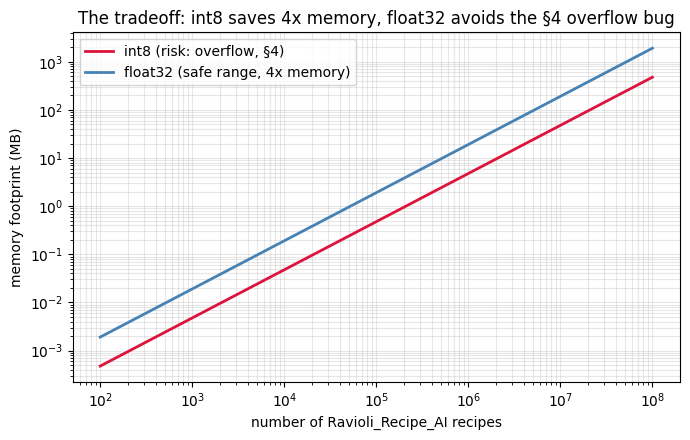

In [5]:
n_recipes = np.logspace(2, 8, 25).astype(int)
mb_int8 = [dtype_memory_for_array('int8', (n, 5))['total_MB'] for n in n_recipes]
mb_f32  = [dtype_memory_for_array('float32', (n, 5))['total_MB'] for n in n_recipes]

fig, ax = plt.subplots(figsize=(7,4.5))
ax.loglog(n_recipes, mb_int8, label='int8 (risk: overflow, §4)', color='crimson', lw=2)
ax.loglog(n_recipes, mb_f32, label='float32 (safe range, 4x memory)', color='steelblue', lw=2)
ax.set_xlabel('number of Ravioli_Recipe_AI recipes')
ax.set_ylabel('memory footprint (MB)')
ax.set_title('The tradeoff: int8 saves 4x memory, float32 avoids the §4 overflow bug')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('ravioli_memory_tradeoff.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Parameter Sweep: Where Exactly Does It Overflow?

Sweep the current ricotta quantity and the AI's adjustment delta; shade
where the int8-stored result goes negative -- the exact boundary a real
quantized system would need input validation or a wider dtype to avoid.


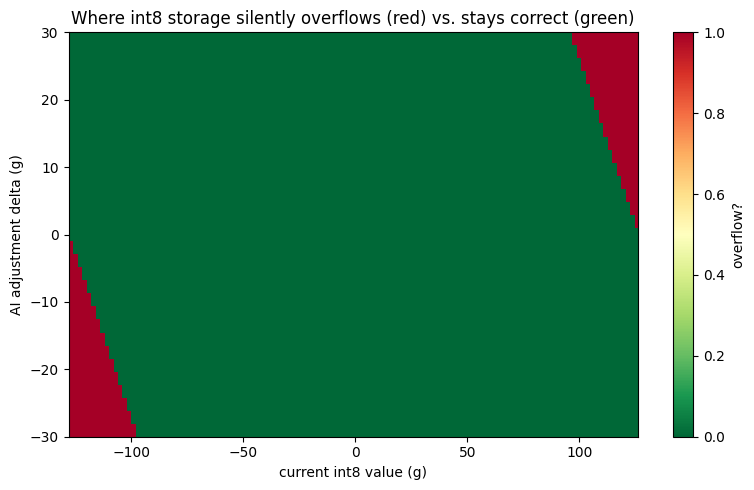

In [6]:
current_vals = np.arange(-128, 128, 2)
deltas = np.arange(-30, 31, 2)
overflow_grid = np.zeros((len(deltas), len(current_vals)), dtype=bool)
for i, d in enumerate(deltas):
    for j, c in enumerate(current_vals):
        result = predict_signed_overflow(int(c), int(d), n_bits=8)
        naive = c + d
        overflow_grid[i, j] = (result != naive)

fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(overflow_grid, extent=[current_vals[0], current_vals[-1], deltas[0], deltas[-1]],
               aspect='auto', origin='lower', cmap='RdYlGn_r')
ax.set_xlabel('current int8 value (g)'); ax.set_ylabel('AI adjustment delta (g)')
ax.set_title('Where int8 storage silently overflows (red) vs. stays correct (green)')
plt.colorbar(im, ax=ax, label='overflow?')
plt.tight_layout()
plt.savefig('ravioli_overflow_boundary.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Command Reference: Inspecting Bytes and Two's Complement from the Shell

Real Unix tools for looking at raw bytes/hex (man-page one-liners), with a
cross-platform Python equivalent next to each (since `xxd`/`od` aren't
available by default on Windows -- these Python lines work everywhere):

| command | what it shows | Python equivalent |
|---|---|---|
| `man ascii` | ASCII table, byte values 0-127 | `[chr(i) for i in range(128)]` |
| `xxd file` | hex + ASCII dump of a file's raw bytes | `data.hex()` |
| `od -tx1 file` | octal-dump, one hex byte per column | `' '.join(f'{b:02x}' for b in data)` |
| `printf '%d\n' 0xFF` | interpret hex as a (signed/unsigned) integer | `int('FF', 16)` |
| `file somefile` | guess a file's type from its byte signature (magic number) | `open(f,'rb').read(4)` |


In [7]:
# Cross-platform Python equivalents, run directly (no shell dependency)
ricotta_int8 = np.int8(120)
raw_bytes = ricotta_int8.tobytes()
print(f"ricotta_int8 = {ricotta_int8}")
print(f"raw bytes (like `xxd`):  {raw_bytes.hex()}")
print(f"as unsigned (like `od -tx1` reinterpreted): {int.from_bytes(raw_bytes, 'little', signed=False)}")
print(f"as signed   (like `printf` with %d on a signed cast): {int.from_bytes(raw_bytes, 'little', signed=True)}")


ricotta_int8 = 120
raw bytes (like `xxd`):  78
as unsigned (like `od -tx1` reinterpreted): 120
as signed   (like `printf` with %d on a signed cast): 120


## 8. Engineering Interpretation

- This is the exact tradeoff behind real int8-quantized neural network
  inference (`dgs/computer_architecture.py`'s dtype table already lists
  int8/uint8 alongside float32/bfloat16 for this reason): 4x smaller
  weights, but every accumulation needs either a wider accumulator dtype
  or explicit saturating (clamped, not wrapped) arithmetic to avoid §4's bug.
- §3's real-gcc verification matters precisely because Python integers
  don't silently overflow -- this notebook's Python-side "prediction"
  functions could be self-consistent but WRONG about what real hardware
  does; checking against an actual compiled program is what makes the
  claim trustworthy.


## 9. Research Discussion

- Real quantized-inference frameworks (e.g. TensorRT, PyTorch quantization)
  use SATURATING arithmetic (clamp to [-128,127]) rather than wrapping --
  a deliberate design choice to avoid exactly the §4 bug. Worth adding a
  `predict_saturating_add` alongside the existing wrapping
  `predict_signed_overflow` to compare both behaviors side by side.
- Could §6's overflow-boundary sweep be extended to int16/int32 quantized
  accumulators, showing how much headroom a wider accumulator buys before
  the same visualization technique shows a boundary at all?


## 10. Possible Experiments

1. Add saturating (clamped) arithmetic to `dgs/machine_modular_arithmetic.py`
   and re-run §4/§6 to show the bug disappearing entirely under that
   alternative overflow policy.
2. Extend the §5 memory comparison to a REAL quantized ML model's weight
   tensor shapes (not the toy 5-ingredients-per-recipe shape here).
3. Verify int16 storage removes the §4 bug entirely for realistic
   ingredient-quantity ranges (grams rarely exceed a few hundred), trading
   2x memory for headroom.


## 11. Future Improvements

- If this playful framing ever becomes a real teaching module, move the
  Ravioli_Recipe_AI-specific numbers (§4, §6) into a small dedicated
  dgs/ module so they're independently testable, rather than living only
  in this notebook's cells.
- §7's command-reference table could be extended with a real subprocess
  call to `xxd`/`od` on a Unix/WSL environment, falling back to the
  Python-only equivalents shown here when those tools aren't available
  (e.g. plain Windows) -- skipped here to keep this notebook portable.
